Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [2]:
# Social
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_34352\544085516.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_34352\544085516.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_34352\544085516.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_ui.csv", index_col=0)


In [19]:
df_rnp

,codecommune,Annee,pop,propf,prop014,prop1539,prop4059,prop60p,petranger,pcapi,...,revmoy,vote_EG_pres,abstention_pres,vote_RN_pres,vote_EG_leg,abstention_leg,vote_RN_leg,total_equipements,seuil,traitée
0,01001,1995,662,0.471756,0.268702,0.280916,0.258015,0.192366,0.016320,0.294118,...,12110.340,0.076056,0.201285,0.225352,NaN,NaN,NaN,0.0,0.0,0
1,01001,1996,678,0.468657,0.270149,0.270149,0.265672,0.194030,0.017366,0.297521,...,11530.236,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
2,01001,1997,695,0.467930,0.272595,0.259475,0.271137,0.196793,0.016997,0.298387,...,12207.807,NaN,NaN,NaN,0.098639,0.337607,0.200680,0.0,0.0,0
3,01001,1998,711,0.465714,0.272857,0.250000,0.278571,0.198571,0.018006,0.305882,...,12892.058,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
4,01001,1999,728,0.463687,0.273743,0.240223,0.284916,0.201117,0.018945,0.307692,...,12839.338,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323199,90105,2018,180,0.414141,0.272727,0.404040,0.303030,0.020202,0.010695,0.427184,...,17467.932,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
323200,90105,2019,179,0.399038,0.288462,0.413462,0.288462,0.009615,0.005236,0.427273,...,17181.760,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
323201,90105,2020,183,0.386047,0.306977,0.418605,0.274419,0.000000,0.005076,0.435897,...,16893.844,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0
323202,90105,2021,186,0.374449,0.325991,0.418502,0.255507,0.000000,0.000000,0.444444,...,16000.777,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0


Fonction d'attribution du traitement

In [3]:
def traitement(df):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 1997].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * 0.6

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    df['traitée'] = (df['total_equipements'] < df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

In [4]:
1+(12-6)/6

2.0

In [5]:
def traitement_bis(df):
    # 1. On définit notre seuil de référence à partir de l'année 2002
    df_2002 = df[df['Annee'] == 2002]
    
    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['total_equipements']
    df['seuil'] = df['codecommune'].map(mapping_seuil)
    
    # 3. Calcul du pourcentage restant par rapport à 2002
    # La division directe est plus propre. On multiplie par 100 pour un format lisible.
    df['traitement'] = ((df['total_equipements'] == 0)&(df['total_equipements'] < df['seuil'])&(df['Annee'] >2002)).astype(int)

    df['traitement'] = df['traitement'].replace([float('inf')], 0)
    df['traitement'] = df['traitement'].fillna(0)

    
    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])
    
    return df

## Calcul du traitement

### RNP

In [6]:
df_rnp = traitement(df_rnp)

### RP

In [7]:
df_rp = traitement(df_rp)

### UI

In [8]:
df_ui = traitement(df_ui)

### UD

In [9]:
df_ud = traitement(df_ud)

## DID

In [10]:
#df_rnp[(df_rnp['traitement']==1)&(df_rnp['Annee']==2022)]

Definition du modele

In [11]:
def DID (df) :
    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [1995, 2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=['vote_RN_pres', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres['vote_RN_pres'] = df_pres['vote_RN_pres'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('float64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome='vote_RN_pres',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=2,                 # Tester 1 période avant le traitement (pre-trends)
        effects=5,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'pchom', 'paind','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

### RNP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.001193 0.000952 -0.003059  0.000673 48005.0     2021.0 48005.0       2021.0
            Effect_2 -0.004298 0.001224 -0.006698 -0.001898 37836.0     1886.0 37836.0       1886.0
            Effect_3 -0.004354 0.001493 -0.007280 -0.001427 28195.0     1696.0 28195.0       1696.0
            Effect_4 -0.007480 0.001953 -0.011308 -0.003653 18759.0     1383.0 18759.0       1383.0
            Effect_5 -0.009736 0.002930 -0.015480 -0.003993  9256.0      801.0  9256.0        801.0
Average_Total_Effect -0.004629 0.001205 -0.006990 -0.002268 53797.0     7787.0 53797.0       7787.0
           Placebo_1  0.003500 0.001221  0.001105  0.005894 37136.0     1211.0 37136.0       1211.0
           Placebo_2  0.000484 0.002097 -0.003626  0.004595 17863.0      500.0 17863.0        500.0
Test of joint nullity of the effec

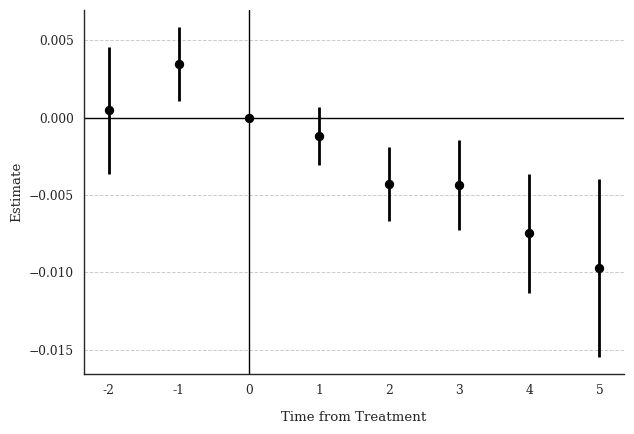

In [12]:
DID(df_rnp)

In [13]:
import scipy.stats as st

# Les valeurs de votre test Placebo
estimate_placebo = 0.006144 
se_placebo =   0.005294

# 1. Calcul du Z-score
z_score = estimate_placebo / se_placebo

# 2. Calcul de la p-value bilatérale
p_value = 2 * (1 - st.norm.cdf(abs(z_score)))

print(f"Z-score : {z_score:.3f}")
print(f"P-value du Placebo : {p_value:.3f}")

Z-score : 1.161
P-value du Placebo : 0.246


### RP

In [14]:
df_rnp['codecommune'][(df_rnp['traitée']==1)&(df_rnp['Annee']<2002)].unique()

<ArrowStringArray>
['01058', '01073', '01083', '01104', '01174', '01188', '01258', '01269',
 '01272', '01274',
 ...
 '88430', '88462', '89073', '89092', '89134', '89163', '89277', '89344',
 '89351', '89353']
Length: 1276, dtype: str

In [15]:
df_rp['codecommune'][(df_rp['traitée']==1)&(df_rp['Annee']<2002)].unique()

<ArrowStringArray>
['01032', '01065', '01069', '01072', '01096', '01123', '01124', '01159',
 '01179', '01184',
 ...
 '91111', '91130', '91175', '91378', '91544', '95308', '95523', '95592',
 '95625', '95641']
Length: 1347, dtype: str

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.002061 0.000918 -0.003860 -0.000263 49007.0     1912.0 49007.0       1912.0
            Effect_2 -0.003322 0.001160 -0.005595 -0.001049 38761.0     1811.0 38761.0       1811.0
            Effect_3 -0.003347 0.001443 -0.006176 -0.000519 29029.0     1648.0 29029.0       1648.0
            Effect_4 -0.005110 0.001860 -0.008756 -0.001464 19462.0     1403.0 19462.0       1403.0
            Effect_5 -0.004714 0.002703 -0.010012  0.000583  9732.0      822.0  9732.0        822.0
Average_Total_Effect -0.003491 0.001205 -0.005853 -0.001130 54701.0     7596.0 54701.0       7596.0
           Placebo_1  0.002523 0.001256  0.000062  0.004984 38029.0     1087.0 38029.0       1087.0
           Placebo_2  0.001866 0.002459 -0.002954  0.006686 18463.0      407.0 18463.0        407.0
Test of joint nullity of the effec

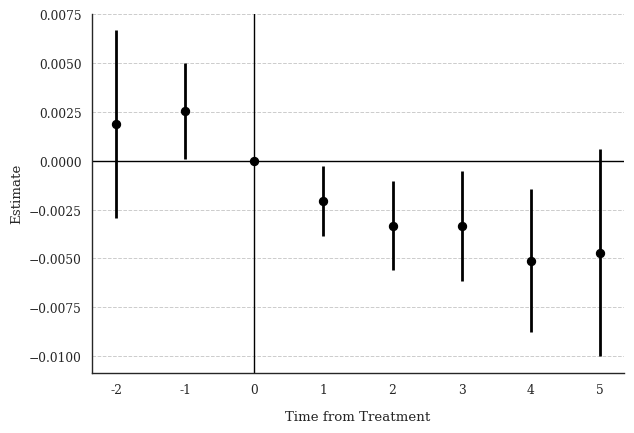

In [16]:
DID(df_rp)

### UI

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1 -0.000919 0.001556 -0.003969 0.002130 14635.0      464.0 14635.0        464.0
            Effect_2  0.000233 0.002084 -0.003852 0.004318 11612.0      452.0 11612.0        452.0
            Effect_3  0.003400 0.002747 -0.001985 0.008785  8734.0      422.0  8734.0        422.0
            Effect_4  0.004156 0.003699 -0.003094 0.011407  5886.0      370.0  5886.0        370.0
            Effect_5  0.006053 0.005480 -0.004688 0.016793  2957.0      205.0  2957.0        205.0
Average_Total_Effect  0.002034 0.002353 -0.002577 0.006646 16086.0     1913.0 16086.0       1913.0
           Placebo_1 -0.001407 0.001839 -0.005013 0.002198 11416.0      258.0 11416.0        258.0
           Placebo_2 -0.002901 0.004350 -0.011427 0.005626  5597.0       81.0  5597.0         81.0
Test of joint nullity of the effects: p-val

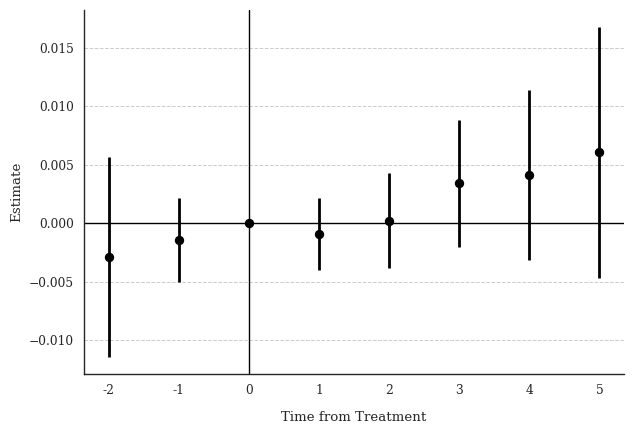

In [17]:
DID(df_ui)

### UD

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.003707 0.005207 -0.006498  0.013913 2008.0       32.0 2008.0         32.0
            Effect_2 -0.004713 0.006933 -0.018300  0.008875 1998.0       32.0 1998.0         32.0
            Effect_3  0.014625 0.010109 -0.005188  0.034437 1340.0       30.0 1340.0         30.0
            Effect_4  0.005890 0.011365 -0.016384  0.028165 1338.0       30.0 1338.0         30.0
            Effect_5 -0.005014 0.013211 -0.030907  0.020879  675.0       21.0  675.0         21.0
Average_Total_Effect  0.003296 0.007937 -0.012261  0.018854 3431.0      145.0 3431.0        145.0
           Placebo_1 -0.008241 0.010935 -0.029673  0.013190 1321.0       11.0 1321.0         11.0
           Placebo_2 -0.039818 0.003578 -0.046832 -0.032804  656.0        2.0  656.0          2.0
Test of joint nullity of the effects: p-value = 0.00

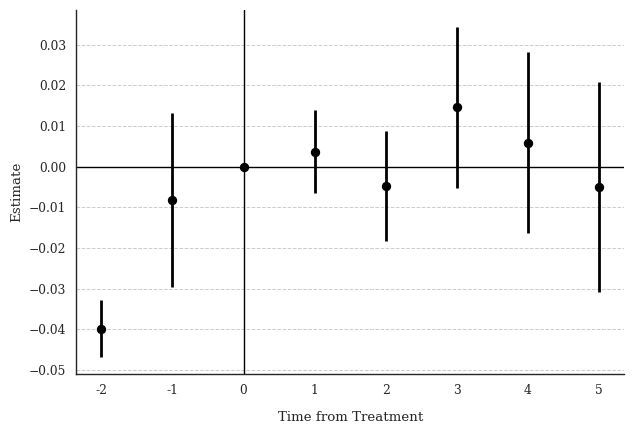

In [18]:
DID(df_ud)

In [20]:
df_test = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)
df_test['codecommune'] = df_test['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_34352\1623403117.py:1: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_transactionnel_rnp.csv", index_col=0)


In [21]:
df_test[df_test['total_equipements']>0]

,codecommune,Annee,pop,propf,prop014,prop1539,prop4059,prop60p,petranger,pcapi,...,pbac,psup,revmoy,vote_EG_pres,abstention_pres,vote_RN_pres,vote_EG_leg,abstention_leg,vote_RN_leg,total_equipements
22,01001,2017,776,0.498688,0.209974,0.217848,0.370079,0.202100,0.010309,0.297386,...,0.430631,0.243243,19859.061,0.136970,0.153846,0.254545,0.096736,0.436455,0.181009,1.0
23,01001,2018,771,0.501976,0.210804,0.206851,0.380764,0.201581,0.008997,0.267974,...,0.434705,0.241503,20854.352,NaN,NaN,NaN,NaN,NaN,NaN,1.0
24,01001,2019,779,0.501323,0.211640,0.195767,0.391534,0.201058,0.007702,0.237942,...,0.436945,0.238011,21015.090,NaN,NaN,NaN,NaN,NaN,NaN,1.0
25,01001,2020,781,0.504648,0.212483,0.184595,0.402390,0.200531,0.006410,0.207668,...,0.440917,0.236332,21443.418,NaN,NaN,NaN,NaN,NaN,NaN,1.0
26,01001,2021,784,0.506667,0.213333,0.173333,0.413333,0.200000,0.006394,0.177215,...,0.444056,0.234266,21529.191,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323147,90096,2022,273,0.397727,0.230114,0.238636,0.383523,0.147727,0.047138,0.890909,...,0.604082,0.383673,20949.492,0.160000,0.164609,0.390000,0.164062,0.456790,0.328125,1.0
323173,90101,2020,238,0.521429,0.035714,0.250000,0.342857,0.371429,0.007937,0.820513,...,0.278846,0.139423,16277.682,NaN,NaN,NaN,NaN,NaN,NaN,1.0
323174,90101,2021,233,0.519031,0.024221,0.245675,0.339100,0.391003,0.007968,0.941176,...,0.279621,0.137441,15770.765,NaN,NaN,NaN,NaN,NaN,NaN,1.0
323175,90101,2022,229,0.513605,0.013605,0.241497,0.336735,0.408163,0.008000,1.000000,...,0.287037,0.138889,15502.554,0.120513,0.184615,0.519231,0.141304,0.532995,0.358696,1.0
